In [45]:
import pandas as pd
# Read IO table
#io_df=pd.read_csv('2019_SML.csv') # OECD Format
code_guide=pd.read_excel('Sector_Codes.xlsx')
code_guide['Code']= code_guide['Code'].astype('str')
io_df=pd.read_csv('matrix_eu-ic-io_ind-by-ind_24ed_2022.csv',index_col=0) # Figaro Format
sel_region='SE'
row_indices = io_df.reset_index().applymap(lambda x: isinstance(x, str) and x.startswith(sel_region)).any(axis=1)
row_indices = row_indices[row_indices].index.tolist()
col_indices = [idx for idx, col in enumerate(io_df.columns) if col.startswith(sel_region)]
sel_df = io_df.reset_index().set_index('rowLabels').iloc[row_indices[0]:row_indices[-1]+1, row_indices[0]:row_indices[-1]+1] 
codes=sel_df.index



C:\Users\MarlonVieiraPassos\AppData\Local\Temp\ipykernel_29212\1721095607.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  row_indices = io_df.reset_index().applymap(lambda x: isinstance(x, str) and x.startswith(sel_region)).any(axis=1)


In [ ]:
io_df

In [ ]:
sel_df

In [46]:
# Read input dictionaries
contributions= {'crop_yield_total': 0.44, 'livestock': 0.45, 'discharge': 0.65, 'groundwater':0.10 ,'hydro_prod': 0.44}
sector_codes= {'Crop and animal production, hunting and related service activities': 'A01', 
               'Electricity, gas, steam and air conditioning supply': 'D35',
              'Water collection, treatment and supply': 'E36'}
sector_vars= {'A01': ['crop_yield_total'],
             'D35': ['hydro_prod'],
             'E36': ['discharge'],
             }
def process_df(df):
    if df.shape[0] > 1 and df.shape[1] > 1:
        return (df,
                [(r, s) for r, s in df.index.str.split('_', n=1)],
                [(r, s) for r, s in df.columns.str.split('_', n=1)])
    elif df.shape[0] == 1:
        return (df,
                df.index.to_list(),
                [(r, s) for r, s in df.columns.str.split('_', n=1)])
    else:
        return (df,
                [(r, s) for r, s in df.index.str.split('_', n=1)],
                df.columns.to_list())
# Code adapted from 'iopy' Library to calculate economic variables from IO table
# More information on the variables found in https://github.com/WWakker/iopy
rs= 64*46 # number of sectors times number of countries
"""  Created on 03/10/2022::
------------- matrix -------------
**Authors**: W. Wakker

"""
import numpy as np


class Matrix(np.ndarray):

    def __new__(cls, info, input_array, rows, columns):
        obj = np.asarray(input_array).view(cls)
        assert len(obj.shape) == 2, "Array must be 2-dimensional"
        assert obj.shape == (len(rows), len(columns)), "Rows and columns do not have the shape of the array"
        obj.info = info
        obj.rows = rows
        obj.columns = columns
        return obj

    def __array_finalize__(self, obj):
        self.info = getattr(obj, 'info', None)
        self.rows = getattr(obj, 'rows', None)
        self.columns = getattr(obj, 'columns', None)

    @property
    def I(self):
        """Invert matrix

        Returns:
            Inverted matrix
        """
        return np.linalg.inv(self)

    @property
    def T(self):
        """Transpose rows and columns

        Returns:
            Transposed Matrix
        """
        m = self.copy()
        m.rows, m.columns = m.columns, m.rows
        return np.transpose(m)

    def transpose(self):
        """Transpose rows and columns

        Returns:
            Transposed Matrix
        """
        m = self.copy()
        m.rows, m.columns = m.columns, m.rows
        return np.transpose(m)

    def flatten(self):
        """Convert to flattened numpy array

        Returns:
            flattened numpy array
        """
        m = np.array(self)
        return m.flatten()

    def to_numpy(self):
        """Convert to numpy array

        Returns:
            numpy array
        """
        return np.asarray(self)
Z = Matrix('Intermediate use',
           *process_df(io_df.iloc[:rs, :rs]))

FD_GRAN = Matrix('Final demand granular',
                 io_df.iloc[:rs, rs:],
                 rows=[(r, s) for r, s in io_df.iloc[:rs, rs:].index.map(str).str.split('_', n=1)],
                 columns=[(r, s) for r, s in io_df.iloc[:rs, rs:].columns.map(str).str.split('_', n=1)])

FD = Matrix('Final demand',
            FD_GRAN.sum(1).reshape(-1, 1),
            rows=Z.rows,
            columns=['FD'])

X = Matrix('X', # Output
           FD + Z.sum(1).reshape(-1, 1),
           rows=Z.rows,
           columns=['X'])

V = Matrix('GVA',
           (X.flatten() - Z.sum(0).flatten()).reshape(1, len(X)),
           rows=['GVA'],
           columns=Z.columns)


In [47]:
def plot_shock(A,
               ax,
               codes,
               codes_abbrev,
               shock_df_dict,
               node_size_list=None,
               node_size_multiple=900, 
               edge_size_multiple=1,
               layout_type='circular',
               layout_seed=1234,
               tol=None):  # clip entries below tol
    
    #print(node_size_list) # debug node colors
    
    # Create the light colormap 
    vmin = tol
    vmax = 100  # Use fixed value
    center = (vmin + vmax) / 2  # Calculate a sensible center point
    
    hex_list = ['#ade8f4', '#d6f6eb', '#fdf1d2', '#faaaae']
    light_cmap = get_continuous_cmap(hex_list)
    
    # Create a consistent normalization - use LogNorm for both the colormap and colorbar
    norm = mcolors.LogNorm(vmin=tol, vmax=vmax)
    
    G = nx.DiGraph()
    N = len(A)
    # Set the diagonal to zero to remove self-loops (sectors that use own outputs as inputs)
    np.fill_diagonal(A, 0)

    # Filter nodes and edges based on GVA losses threshold (tol)
    filtered_nodes = []
    filtered_node_sizes = []
    for i in range(N):
        if node_size_list[i] > tol:
            filtered_nodes.append(codes[i])
            filtered_node_sizes.append(node_size_list[i])
            
    # Add nodes without weights initially
    for i in range(len(filtered_nodes)):
        G.add_node(filtered_nodes[i], name=filtered_nodes[i])

    # Position the nodes
    if layout_type == 'circular':
        node_pos_dict = nx.circular_layout(G)
    elif layout_type == 'spring':
        node_pos_dict = nx.spring_layout(G, seed=layout_seed)
    elif layout_type == 'random':
        node_pos_dict = nx.random_layout(G, seed=layout_seed)
    elif layout_type == 'spiral':
        node_pos_dict = nx.spiral_layout(G)

    # Add the filtered nodes to the graph
    G.add_nodes_from(filtered_nodes)
    
    # Apply the same normalization for node colors
    node_colors = light_cmap(norm(filtered_node_sizes))
    
    # Adjust the node sizes by adding the offset and applying a logarithmic transformation
    adjusted_node_sizes = np.log(np.array(filtered_node_sizes))
    adjusted_node_sizes = [element*node_size_multiple for element in adjusted_node_sizes]
    
    # Plot the network nodes for combined losses
    node_collection = nx.draw_networkx_nodes(G, 
                           node_pos_dict, 
                           nodelist=filtered_nodes, 
                           node_color=node_colors, 
                           node_size=adjusted_node_sizes, 
                           edgecolors='grey', 
                           linewidths=2, 
                           alpha=1,
                           ax=ax)

    # Draw labels 
    for node, (x, y) in node_pos_dict.items():
        if node in filtered_nodes:
            n = codes.index(node)
            font_size = 9
            label = codes_abbrev[n]
            ax.text(x, y, label, fontsize=font_size, ha='center', va='center')
            
    # Draw edges for each hazard type
    hazards=['Flood', 'Drought', 'Heatwave']
    edge_colors={'Flood':'#1f77b4', 'Drought': '#000000', 'Heatwave': '#d62728'}
    edge_styles={'Flood':'solid', 'Drought': 'solid', 'Heatwave': 'solid'}
    edge_connections={'Flood':'arc3,rad=0.1', 'Drought': 'arc3,rad=0.3', 'Heatwave': 'arc3,rad=0.5'}
    
    for hazard in hazards:
        G_plot=G.copy()
        shock_df=shock_df_dict[hazard]
        edge_weights = []
        for i in range(N):
            for j in range(N):
                a = A[i,j]*shock_df.loc[shock_df['Code'] == codes[i], 'Final shock'].values[0]*(-1)
                if codes[i] in filtered_nodes and codes[j] in filtered_nodes:
                    G_plot.add_edge(codes[i], codes[j], weight=a)
                    edge_weights.append(a)
                    
        edge_weights = np.sqrt(np.array(edge_weights))
        edge_weights = [element*edge_size_multiple for element in edge_weights]
        
        nx.draw_networkx_edges(G_plot, 
                               node_pos_dict, 
                               edge_color=edge_colors[hazard], 
                               style=edge_styles[hazard],
                               node_size=adjusted_node_sizes,
                               width=edge_weights, 
                               arrows=True, 
                               arrowsize=20, 
                               alpha=1,
                               ax=ax, 
                               arrowstyle='->',
                               connectionstyle=edge_connections[hazard])
    
    node_collection.set_zorder(0)
    
    # Use the same normalization for the colorbar
    sm = cm.ScalarMappable(norm=norm, cmap=light_cmap)
    
    # Add the colorbar
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03) 
    
    # Set nice tick values for logarithmic scale
    # Using 5 tick points between tol and vmax that make sense on a log scale
    log_ticks = np.logspace(np.log10(tol), np.log10(vmax), 5)
    cbar.set_ticks(log_ticks)
    cbar.set_ticklabels([f"{int(tick) if tick.is_integer() else round(tick, 1)}" for tick in log_ticks])
    cbar.set_label('GVA losses (million euros)', size=SIZE_DEFAULT)
    
    # --- Create the legend ---
    # Function to create a custom legend entry with an arrow
    def create_legend_arrow(color, label, linestyle):
        return mlines.Line2D([], [], color=color, label=label, linestyle=linestyle,
                             marker=r'$\longrightarrow$', markersize=30, markeredgewidth=0.15, linewidth=0)
    
    # Create custom lines with arrows for the legend
    flood_legend = create_legend_arrow(edge_colors['Flood'], 'Flood', edge_styles['Flood'])
    drought_legend = create_legend_arrow(edge_colors['Drought'], 'Drought', edge_styles['Drought'])
    heatwave_legend = create_legend_arrow(edge_colors['Heatwave'], 'Heatwave', edge_styles['Heatwave'])

    # Add the legend to the plot
    plt.legend(handles=[flood_legend, drought_legend, heatwave_legend], loc='upper center', 
               ncol=3, bbox_to_anchor=(0.50, 1.05),
               title='Cascading economic shocks ('+str(int(year))+')')
    
    plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.25)
    plt.savefig('fig_shock_'+str(int(year))+'.png', dpi=300, bbox_inches='tight')
    
    return G

In [39]:
# Calculate losses or gains automatically for multiple years and sectors
# Print total losses or gains per sector per year for comparison using 2022 as the base year

def estimate_shocks(io_df, anomalies, damage, year, sel_region, tol):
    print('\nAnomaly year: '+str(year))
    # Filter table for region
    row_indices = io_df.reset_index().applymap(lambda x: isinstance(x, str) and x.startswith(sel_region)).any(axis=1)
    row_indices = row_indices[row_indices].index.tolist()
    col_indices = [idx for idx, col in enumerate(io_df.columns) if col.startswith(sel_region)]
    sel_df = io_df.reset_index().set_index('rowLabels').iloc[row_indices[0]:row_indices[-1]+1, row_indices[0]:row_indices[-1]+1] 
    codes=sel_df.index
    # Read input dictionaries
    contributions= {'crop_yield_total': 0.44, 'livestock': 0.45, 'discharge': 0.65, 'groundwater':0.10 ,'hydro_prod': 0.44}
    sector_codes= {'Crop and animal production, hunting and related service activities': 'A01', 
                   'Electricity, gas, steam and air conditioning supply': 'D35',
                  'Water collection, treatment and supply': 'E36',
                  'Insurance, reinsurance and pension funding, except compulsory social security': 'K65'}
    sector_vars= {'A01': ['crop_yield_total'],
                 'D35': ['hydro_prod'],
                 'E36': ['discharge'],
                 'K65': ['damage']}
    outputs=np.array(X[:,0])[row_indices[0]:row_indices[-1]+1] # only for selected region
    gva=np.array(V[0])[row_indices[0]:row_indices[-1]+1] # only for selected region
    Z=np.matrix(sel_df) # matrix of intermediate production only for selected region
    # Compute the Allocation Coefficient Matrix (D)
    outputs[outputs==0] = 1 # Fill output vector to allow inversion
    D = Z / outputs
    # Calculate the Output Inverse (O)
    I = np.identity(len(D))
    O = np.linalg.inv(I - D)
    # Define the initial shock vector s
    s= np.array([0 for code in codes]).astype(float)
    shock_sectors=['K65','A01','E36', 'D35']
    shock_vars=['damage', 'crop_yield_total', 'discharge', 'hydro_prod']
    codes= [code.replace('SE_', '') for code in codes]
    hazards= ['Flood', 'Drought', 'Heatwave', 'Combined']
    shock_df_dict = {}
    for hazard in hazards:
        for shock_sector in shock_sectors:
            # Loop through the dictionary items
            #for title, code in sector_codes.items():
                #if code == shock_sector:
                    #print('\nImpacted sector: '+title)
            shock_vars=sector_vars.get(shock_sector)
            N=0
            for shock_var in shock_vars:
                sector_idx= np.where(np.array(codes)==shock_sector)[0][0]
                if shock_var=='damage' and (hazard=='Flood' or hazard=='Combined'):
                    df_anom=damage[damage['Time']==year]
                    loss_year= df_anom['Loss'].iloc[0]
                    # Calculate the total size of sector K65
                    total_column_sum = sel_df['SE_K65'].sum()  # Sum of the 'SE_K65' column
                    total_row_sum = sel_df.loc['SE_K65'].sum()  # Sum of the 'SE_K65' row
                    # Avoid double-counting the diagonal element (where 'SE_K65' produces for itself)
                    diagonal_value = sel_df.at['SE_K65', 'SE_K65']
                    # Calculate the total size of the sector 'SE_K65'
                    total_size_K65 = total_column_sum + total_row_sum - diagonal_value
                    contribution= (loss_year/total_size_K65)
                    anomaly=np.nan
                    shock_year= -contribution*100
                    print('Contribution from property damage in sector: '+str(contribution*100))
                elif shock_var == 'damage' and (hazard != 'Flood' or hazard != 'Combined'):
                    shock_year=0
                    anomaly=0
                    contribution= 0
                elif shock_var!='damage':
                    df_anom=anomalies[anomalies['Impact variable']==shock_var]
                    df_anom=df_anom[df_anom['Time']==year]
                    df_anom_haz=df_anom[df_anom['Hazard']==hazard] # Combined or hazard-specific effects 
                    anomaly = df_anom_haz['Attributed impact'].iloc[0]
                    contribution=contributions.get(shock_var)
                    shock_year= anomaly*contribution
                if hazard=='Combined':
                    print('Summary for Combined Hazards')
                    print('Impacted variable: '+shock_var)
                    print('Yearly anomaly (%): '+str(round(anomaly,2)))
                    print('Contribution (%): '+str(round(contribution*100,2)))
                    print('Variable shock (%): '+str(round(shock_year,2)))
                if len(shock_vars)==1:
                    shock_year_total= shock_year
                    s[sector_idx]= shock_year_total # anomalies at corresponding productive sector
                else: 
                    if N==0:
                        shock_year_temp= shock_year
                    if N==1: # second variable of the sector
                        shock_year_total= shock_year+shock_year_temp
                        s[sector_idx]= shock_year_total # anomalies at corresponding productive sector
                N=N+1
        # Compute the propagated shock delta x = Gd
        delta_x = np.dot(s, O) # Equation (6) from (Jenkins, 2021)

        shock_df=pd.DataFrame(columns=['Code','Initial shock', 'Final shock', 'GVA', 'GVA change'])
        shock_df['Code']= codes
        code_guide=pd.read_excel('Sector_Codes.xlsx')
        code_guide['Code']= code_guide['Code'].astype('str')
        shock_df=shock_df.merge(code_guide[['Code','Shortened Title', 'Abbreviation']])
        shock_df['Initial shock']= s
        shock_df['Final shock']= delta_x.A1 # flattened results
        shock_df['GVA']= gva
        shock_df['GVA change']= shock_df['GVA']*shock_df['Final shock']/100
        gva_total=round(shock_df['GVA change'].sum(),2)
        shock_df['Year']=int(year)
        shock_df['Hazard']=hazard
        shock_df_dict[hazard] = shock_df
    print('Total GVA change in '+str(int(year))+' (M Euro): '+str(gva_total))
    node_size_list = [shock_df_dict['Combined'].loc[shock_df_dict['Combined']['Code'] == code, 'GVA change'].values[0]*(-1) for code in codes]
    if gva_total<0:
        try:
            fig, ax = plt.subplots(figsize=(8, 8))
            plt.axis("off")
            codes_abbrev=code_guide['Abbreviation'].values
            G=plot_shock(normalize_matrix(sel_df.values), ax, codes, codes_abbrev, shock_df_dict, layout_type='spring', 
                   node_size_multiple=500, node_size_list=node_size_list, tol=tol) # plot only losses above tol in million euros
        except:
            pass
    return shock_df_dict

In [42]:
import pandas as pd
import xml.etree.ElementTree as ET

# Load and parse the XML file
tree = ET.parse('sek.xml')
root = tree.getroot()

# Define namespaces to handle the XML correctly
namespaces = {
    'ns0': 'http://www.SDMX.org/resources/SDMXML/schemas/v2_0/message',
    'ns2': 'http://www.ecb.europa.eu/vocabulary/stats/exr/1'
}

# Extract the relevant data (the 'Obs' elements)
data_sek = []
for obs in root.findall('.//ns2:Obs', namespaces):
    row = {
        'TIME_PERIOD': obs.get('TIME_PERIOD'),
        'OBS_VALUE': obs.get('OBS_VALUE'),
        'OBS_STATUS': obs.get('OBS_STATUS'),
        'OBS_CONF': obs.get('OBS_CONF')
    }
    data_sek.append(row)

# Create DataFrame from the extracted data
sek_df = pd.DataFrame(data_sek)

# Convert 'TIME_PERIOD' to datetime format and 'OBS_VALUE' to numeric
sek_df['TIME_PERIOD'] = pd.to_datetime(sek_df['TIME_PERIOD'])
sek_df['OBS_VALUE'] = pd.to_numeric(sek_df['OBS_VALUE'], errors='coerce')

# Filter data to only include years 2005-2022
sek_df = sek_df[sek_df['TIME_PERIOD'].dt.year.between(2005, 2022)]

# Set the 'TIME_PERIOD' column as the index
sek_df.set_index('TIME_PERIOD', inplace=True)

# Calculate yearly average of 'OBS_VALUE'
yearly_avg = sek_df[['OBS_VALUE']].resample('Y').mean()

# Reset index to have a proper DataFrame
yearly_avg.reset_index(inplace=True)

# Display the yearly averages
print(yearly_avg)


   TIME_PERIOD  OBS_VALUE
0   2005-12-31   9.282193
1   2006-12-31   9.254387
2   2007-12-31   9.250107
3   2008-12-31   9.615237
4   2009-12-31  10.619054
5   2010-12-31   9.537266
6   2011-12-31   9.029845
7   2012-12-31   8.704066
8   2013-12-31   8.651538
9   2014-12-31   9.098524
10  2015-12-31   9.353461
11  2016-12-31   9.468901
12  2017-12-31   9.635093
13  2018-12-31  10.258258
14  2019-12-31  10.589081
15  2020-12-31  10.484753
16  2021-12-31  10.146463
17  2022-12-31  10.629575


C:\Users\MarlonVieiraPassos\AppData\Local\Temp\ipykernel_29212\2430260589.py:39: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yearly_avg = sek_df[['OBS_VALUE']].resample('Y').mean()


In [48]:
damage_storm= pd.read_excel('Insurance Sweden Damage Storm.xlsx')
damage_water= pd.read_excel('Insurance Sweden Damage Water.xlsx')

In [ ]:
damage_water

In [ ]:
damage_storm

In [49]:
damage = pd.read_excel('Insurance Sweden Damage Water and Storm.xlsx')

# Group by year and sum all damage columns
damage = damage.groupby('År').agg('sum').reset_index()

# Convert all data columns to numeric (except the year column)
damage.iloc[:, 1:] = damage.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')

# Compute total loss across all damage types
damage['Loss'] = damage.iloc[:, 1:].sum(axis=1)

# Keep only year and total loss
damage = damage[['År', 'Loss']]
damage.columns = ['Time', 'Loss']

# Convert SEK to million euros using exchange rate
damage['Loss'] = damage['Loss'] / (yearly_avg['OBS_VALUE'].values * 1e6)


In [ ]:
damage # water and storm


Anomaly year: 2005


C:\Users\MarlonVieiraPassos\AppData\Local\Temp\ipykernel_29212\1099356913.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  row_indices = io_df.reset_index().applymap(lambda x: isinstance(x, str) and x.startswith(sel_region)).any(axis=1)


Contribution from property damage in sector: 11.877730940620811
Contribution from property damage in sector: 11.877730940620811
Summary for Combined Hazards
Impacted variable: damage
Yearly anomaly (%): nan
Contribution (%): 11.88
Variable shock (%): -11.88
Summary for Combined Hazards
Impacted variable: crop_yield_total
Yearly anomaly (%): 0.0
Contribution (%): 44.0
Variable shock (%): 0.0
Summary for Combined Hazards
Impacted variable: discharge
Yearly anomaly (%): -0.75
Contribution (%): 65.0
Variable shock (%): -0.49
Summary for Combined Hazards
Impacted variable: hydro_prod
Yearly anomaly (%): -0.04
Contribution (%): 44.0
Variable shock (%): -0.02
Total GVA change in 2005 (M Euro): -941.55

Anomaly year: 2006


C:\Users\MarlonVieiraPassos\AppData\Local\Temp\ipykernel_29212\1099356913.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  row_indices = io_df.reset_index().applymap(lambda x: isinstance(x, str) and x.startswith(sel_region)).any(axis=1)


Contribution from property damage in sector: 0.975613726255547
Contribution from property damage in sector: 0.975613726255547
Summary for Combined Hazards
Impacted variable: damage
Yearly anomaly (%): nan
Contribution (%): 0.98
Variable shock (%): -0.98
Summary for Combined Hazards
Impacted variable: crop_yield_total
Yearly anomaly (%): -0.1
Contribution (%): 44.0
Variable shock (%): -0.04
Summary for Combined Hazards
Impacted variable: discharge
Yearly anomaly (%): -2.85
Contribution (%): 65.0
Variable shock (%): -1.85
Summary for Combined Hazards
Impacted variable: hydro_prod
Yearly anomaly (%): -1.31
Contribution (%): 44.0
Variable shock (%): -0.58
Total GVA change in 2006 (M Euro): -230.09

Anomaly year: 2007


...

Contribution from property damage in sector: 1.2538110617020677
Contribution from property damage in sector: 1.2538110617020677
Summary for Combined Hazards
Impacted variable: damage
Yearly anomaly (%): nan
Contribution (%): 1.25
Variable shock (%): -1.25
Summary for Combined Hazards
Impacted variable: crop_yield_total
Yearly anomaly (%): 0.0
Contribution (%): 44.0
Variable shock (%): 0.0
Summary for Combined Hazards
Impacted variable: discharge
Yearly anomaly (%): 0.0
Contribution (%): 65.0
Variable shock (%): 0.0
Summary for Combined Hazards
Impacted variable: hydro_prod
Yearly anomaly (%): -0.12
Contribution (%): 44.0
Variable shock (%): -0.05
Total GVA change in 2020 (M Euro): -108.77

Anomaly year: 2021


C:\Users\MarlonVieiraPassos\AppData\Local\Temp\ipykernel_29212\1099356913.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  row_indices = io_df.reset_index().applymap(lambda x: isinstance(x, str) and x.startswith(sel_region)).any(axis=1)


Contribution from property damage in sector: 7.120696254086971
Contribution from property damage in sector: 7.120696254086971
Summary for Combined Hazards
Impacted variable: damage
Yearly anomaly (%): nan
Contribution (%): 7.12
Variable shock (%): -7.12
Summary for Combined Hazards
Impacted variable: crop_yield_total
Yearly anomaly (%): -0.24
Contribution (%): 44.0
Variable shock (%): -0.11
Summary for Combined Hazards
Impacted variable: discharge
Yearly anomaly (%): 0.0
Contribution (%): 65.0
Variable shock (%): 0.0
Summary for Combined Hazards
Impacted variable: hydro_prod
Yearly anomaly (%): 0.0
Contribution (%): 44.0
Variable shock (%): 0.0
Total GVA change in 2021 (M Euro): -566.71

Anomaly year: 2022


C:\Users\MarlonVieiraPassos\AppData\Local\Temp\ipykernel_29212\1099356913.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  row_indices = io_df.reset_index().applymap(lambda x: isinstance(x, str) and x.startswith(sel_region)).any(axis=1)


Contribution from property damage in sector: 2.0876357258854066
Contribution from property damage in sector: 2.0876357258854066
Summary for Combined Hazards
Impacted variable: damage
Yearly anomaly (%): nan
Contribution (%): 2.09
Variable shock (%): -2.09
Summary for Combined Hazards
Impacted variable: crop_yield_total
Yearly anomaly (%): -0.14
Contribution (%): 44.0
Variable shock (%): -0.06
Summary for Combined Hazards
Impacted variable: discharge
Yearly anomaly (%): -8.49
Contribution (%): 65.0
Variable shock (%): -5.52
Summary for Combined Hazards
Impacted variable: hydro_prod
Yearly anomaly (%): -3.48
Contribution (%): 44.0
Variable shock (%): -1.53
Total GVA change in 2022 (M Euro): -577.32


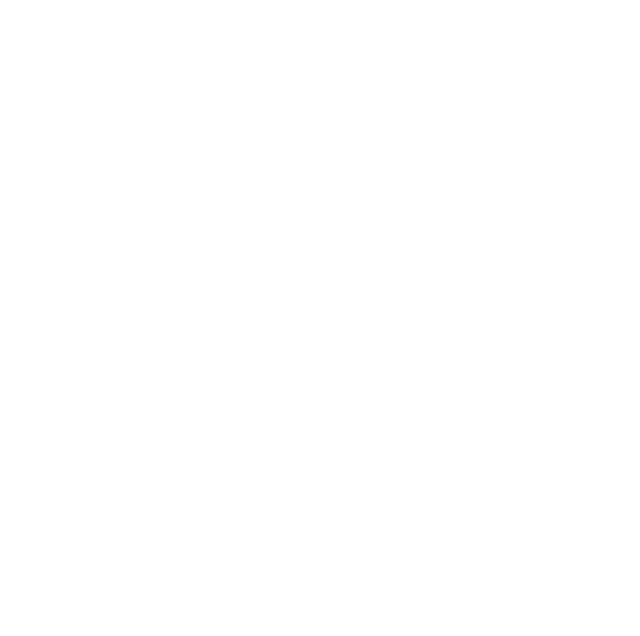

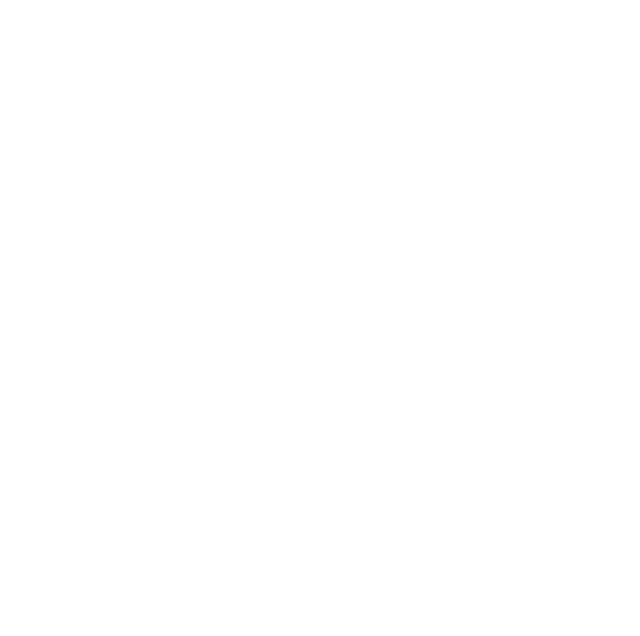

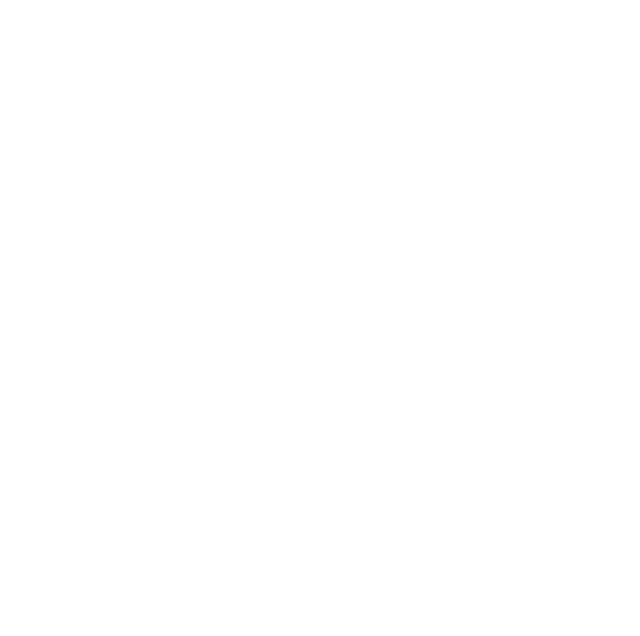

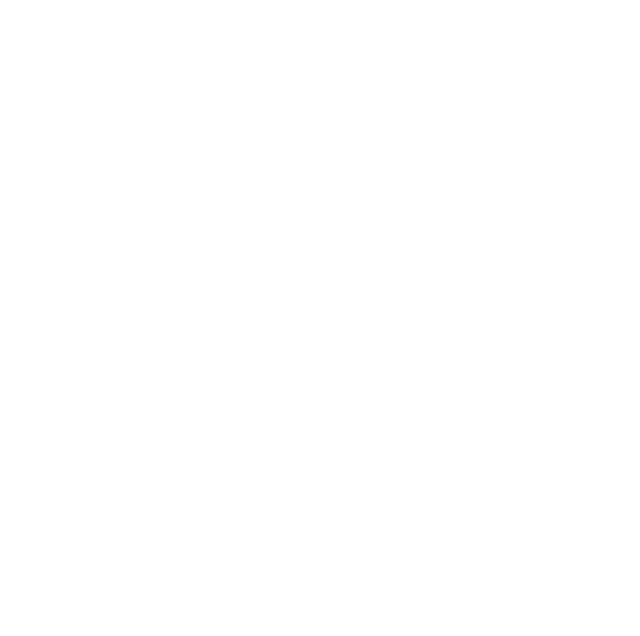

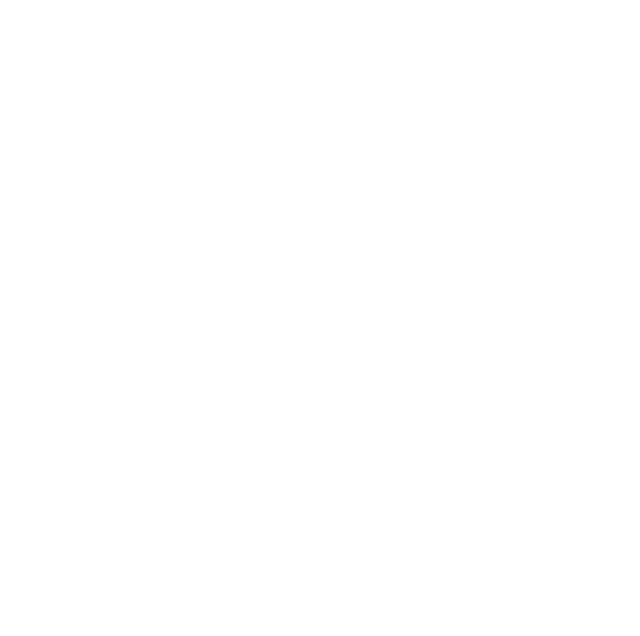

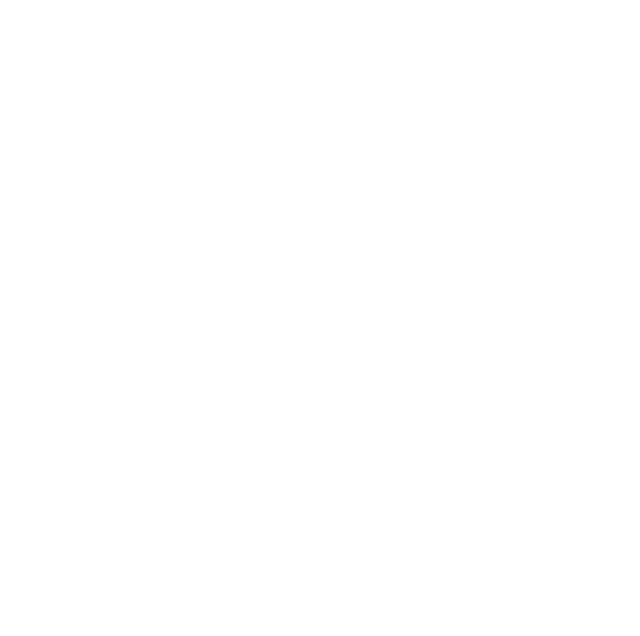

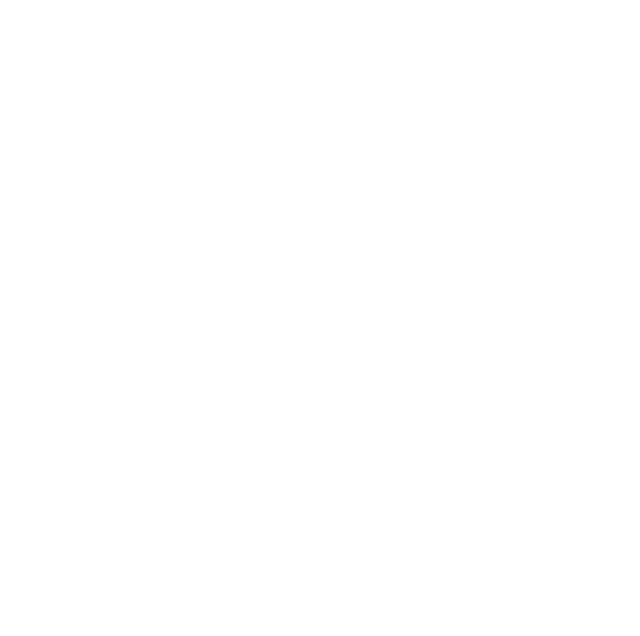

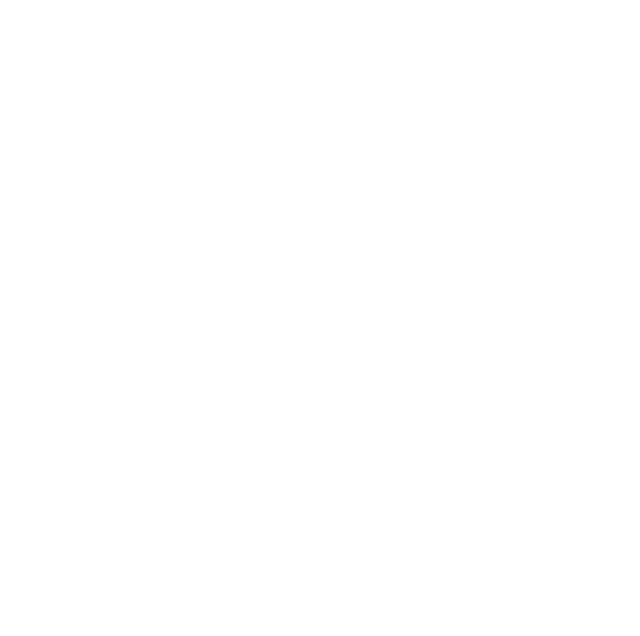

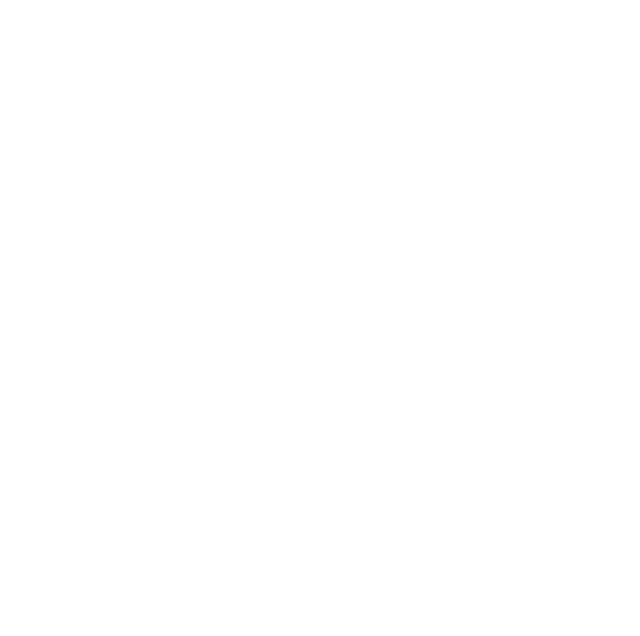

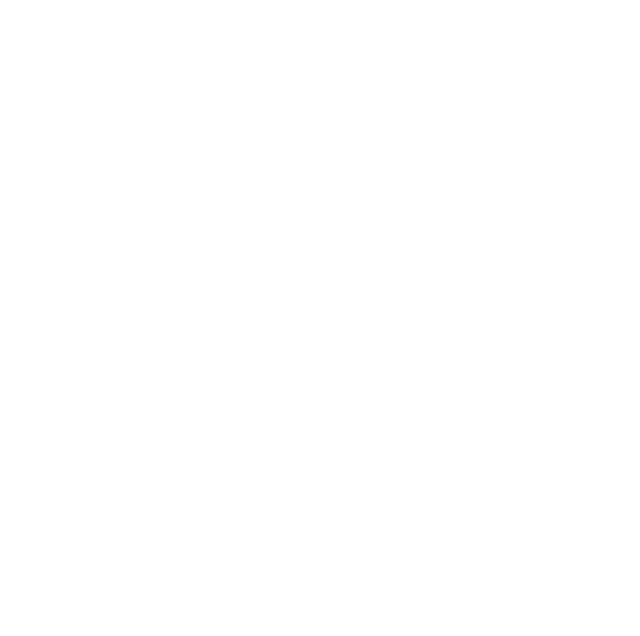

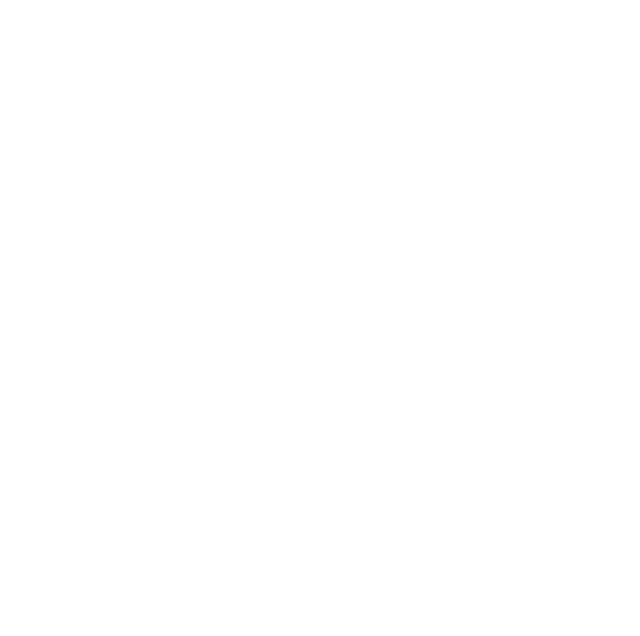

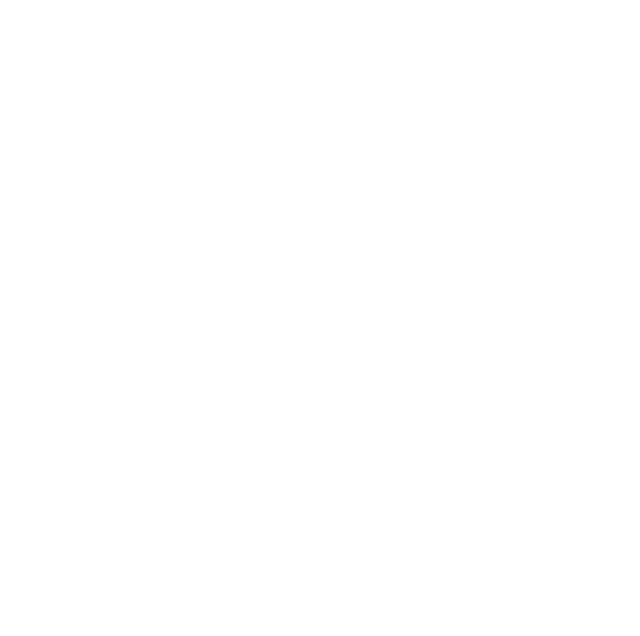

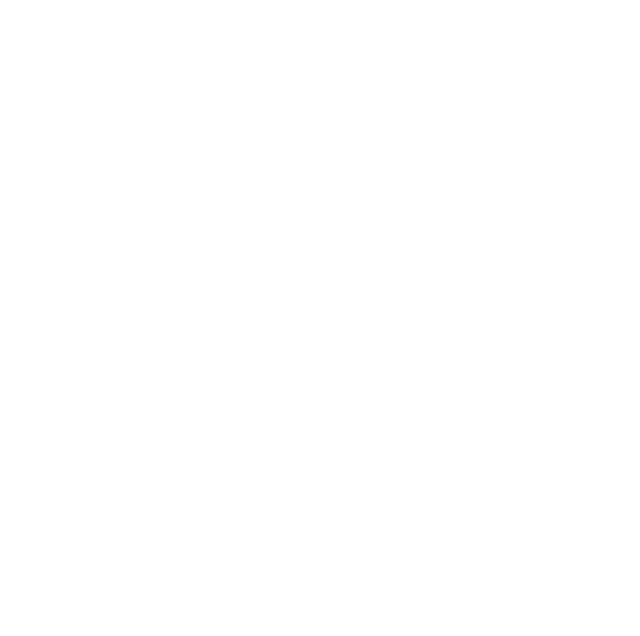

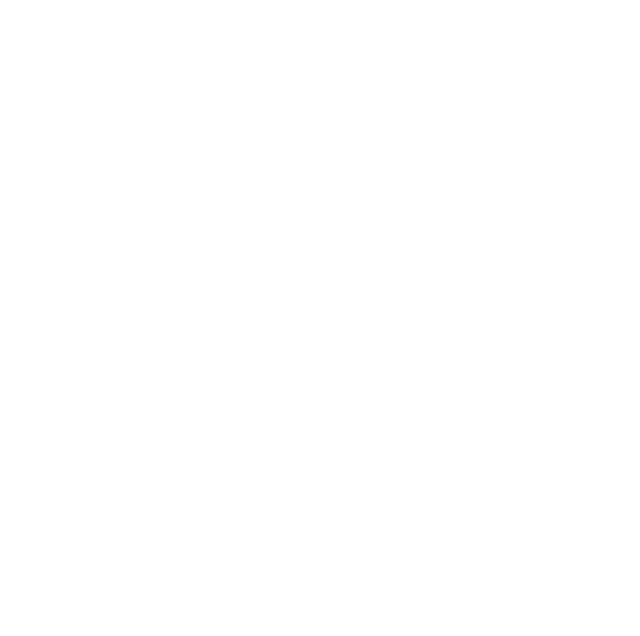

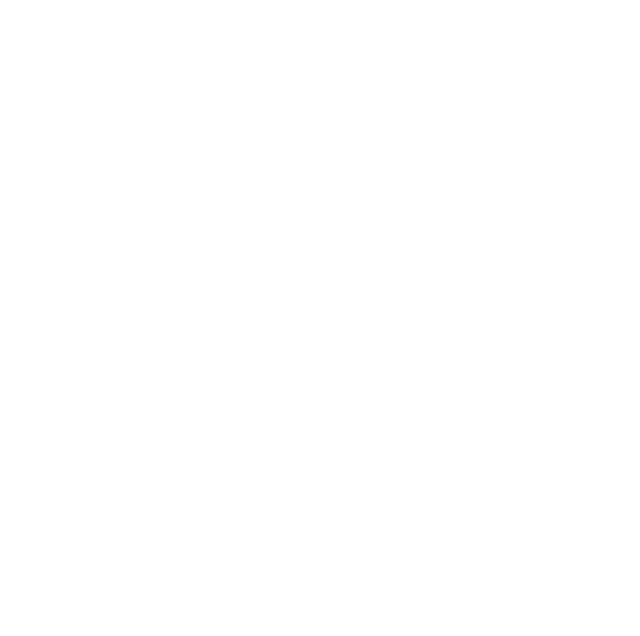

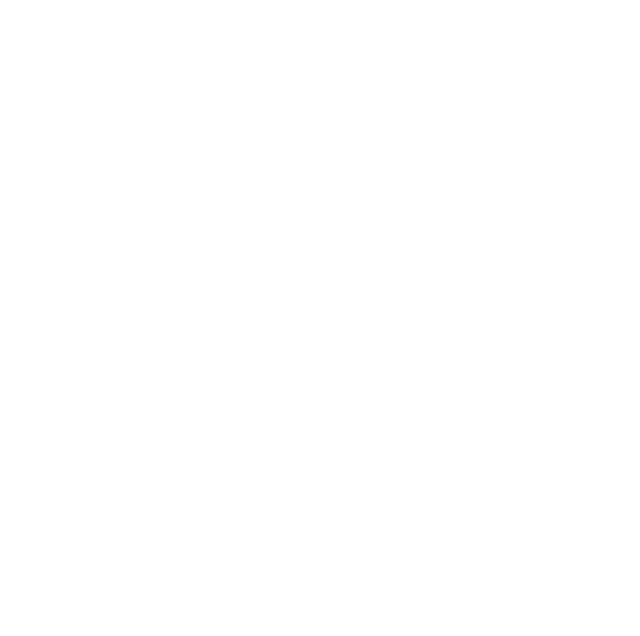

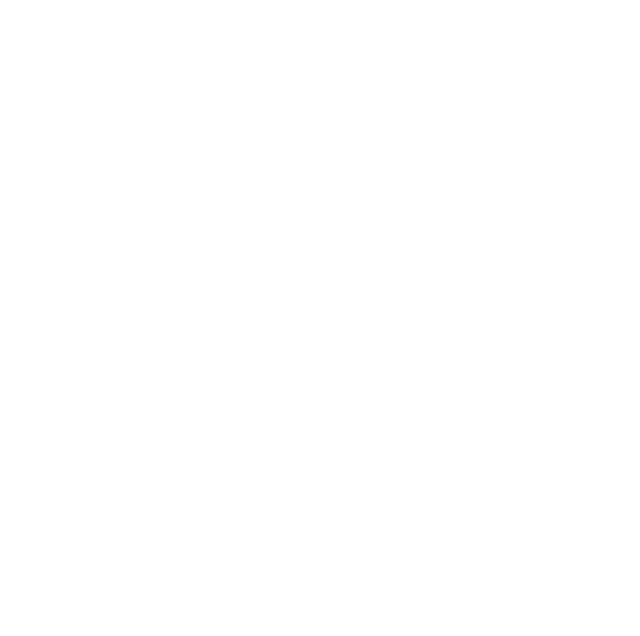

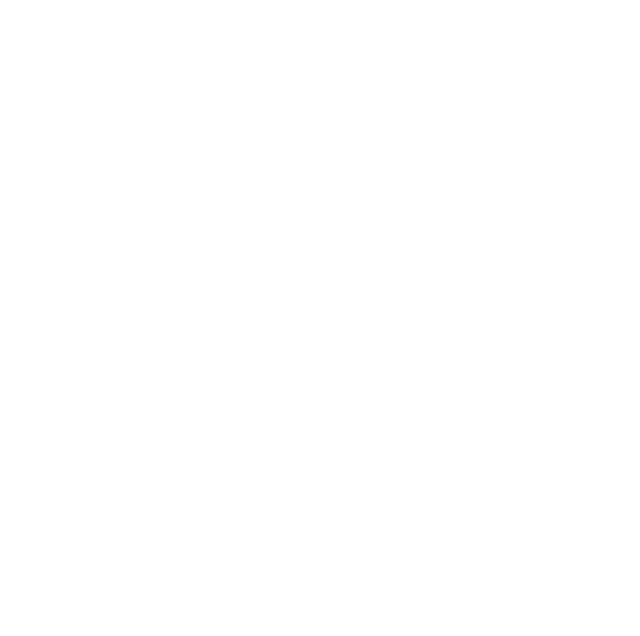

In [50]:
# Only losses
# Read IO table
all_shock_df=pd.DataFrame()
io_df=pd.read_csv('matrix_eu-ic-io_ind-by-ind_24ed_2022.csv', index_col=0) # 2022 base year
# Read negative impacts
anomalies=pd.read_excel('Annual_negative_impacts.xlsx')
anomalies=anomalies.sort_values('Time')
years=anomalies.Time.unique()
#years=[2005, 2013, 2018, 2022]
#years=[2018]
#years=[2013]
#years=[2005]

for year in years:
    if year==2018 or year==2013 or year==2022 or year==2005:
        tol=5
    else:
        tol=3
    shock_df_dict_year=estimate_shocks(io_df, anomalies, damage, year, 'SE', tol)
    # Loop through the dictionary and append each DataFrame
    for key, df in shock_df_dict_year.items():
        all_shock_df = pd.concat([all_shock_df, df], ignore_index=True)

In [ ]:
pd.concat(shock_df_dict_year, ignore_index=True).sort_values('GVA change')

In [ ]:
# Plot shocks, highlighting technical coefficients for edge thickness and losses to GVA magnitudes for node size
 
import networkx as nx
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Define font properties for publication-quality visuals
SIZE_DEFAULT = 16
SIZE_LARGE = 18
plt.rc("font", family="Arial")
plt.rc("font", size=SIZE_DEFAULT)
plt.rc("axes", titlesize=SIZE_LARGE)
plt.rc("axes", labelsize=SIZE_LARGE)
plt.rc("xtick", labelsize=SIZE_DEFAULT)
plt.rc("ytick", labelsize=SIZE_DEFAULT)

def get_continuous_cmap(hex_list, float_list=None):
    ''' creates and returns a color map that can be used in heat map figures.
        If float_list is not provided, colour map graduates linearly between each color in hex_list.
        If float_list is provided, each color in hex_list is mapped to the respective location in float_list. 
        
        Parameters
        ----------
        hex_list: list of hex code strings
        float_list: list of floats between 0 and 1, same length as hex_list. Must start with 0 and end with 1.
        
        Returns
        ----------
        colour map'''
    rgb_list = [rgb_to_dec(hex_to_rgb(i)) for i in hex_list]
    if float_list:
        pass
    else:
        float_list = list(np.linspace(0,1,len(rgb_list)))
        
    cdict = dict()
    for num, col in enumerate(['red', 'green', 'blue']):
        col_list = [[float_list[i], rgb_list[i][num], rgb_list[i][num]] for i in range(len(float_list))]
        cdict[col] = col_list
    cmp = mcolors.LinearSegmentedColormap('my_cmp', segmentdata=cdict, N=256)
    return cmp
def hex_to_rgb(value):
    '''
    Converts hex to rgb colours
    value: string of 6 characters representing a hex colour.
    Returns: list length 3 of RGB values'''
    value = value.strip("#") # removes hash symbol if present
    lv = len(value)
    return tuple(int(value[i:i + lv // 3], 16) for i in range(0, lv, lv // 3))


def rgb_to_dec(value):
    '''
    Converts rgb to decimal colours (i.e. divides each value by 256)
    value: list (length 3) of RGB values
    Returns: list (length 3) of decimal values'''
    return [v/256 for v in value]

# Modified from: Quantecon Library
def normalize_matrix(A):
    A_min = A.min()
    A_max = A.max()
    A_normalized = (A - A_min) / (A_max - A_min)
    return A_normalized

def to_zero_one(x):
    "Map vector x to the zero one interval."
    x = np.array(x)
    x_min, x_max = x.min(), x.max()
    return (x - x_min)/(x_max - x_min)

import matplotlib.cm as cm
def colorise_vector(weights,beta=True, color_palette=cm.rainbow):
    cp = color_palette(to_zero_one(weights))
    return cp 

def colorise_vector_log(weights, tol, color_palette):
    #norm = mcolors.LogNorm(vmin=np.min(weights), vmax=np.max(weights))
    norm = mcolors.LogNorm(vmin=tol, vmax=500)
    cp = color_palette(norm(weights))
    return cp 

def eigenvector_centrality(A, k=40, authority=False):
    """
    Computes the dominant eigenvector of A. Assumes A is
    primitive and uses the power method.
    """
    A_temp = A.T if authority else A
    n = len(A_temp)
    r = np.max(np.abs(np.linalg.eigvals(A_temp)))
    e = r**(-k) * (np.linalg.matrix_power(A_temp, k) @ np.ones(n))
    return e / np.sum(e)

def plot_shock(A,
                        ax,
                        codes,
                        codes_abbrev,
                        shock_df_dict,
                        node_size_list=None,
                        node_size_multiple=900, 
                        edge_size_multiple=1,
                        layout_type='circular',
                        layout_seed=1234,
                        tol=None):  # clip entries below tol

    # Create the light colormap 
    center = 25
    vmax= 100
    divnorm = mcolors.TwoSlopeNorm(vmin=tol,vcenter=center, vmax=vmax)
    hex_list = ['#ade8f4', '#d6f6eb', '#fdf1d2', '#faaaae']
    light_cmap=get_continuous_cmap(hex_list)
    G = nx.DiGraph()
    N = len(A)
    # Set the diagonal to zero to remove self-loops (sectors that use own outputs as inputs)
    np.fill_diagonal(A, 0)

    # Filter nodes and edges based on GVA losses threshold (tol)
    filtered_nodes = []
    filtered_node_sizes = []
    for i in range(N):
        if node_size_list[i] > tol:
            filtered_nodes.append(codes[i])
            filtered_node_sizes.append(node_size_list[i])
            
    # Add nodes without weights initially
    for i in range(len(filtered_nodes)):
        G.add_node(filtered_nodes[i], name=filtered_nodes[i])

    # Position the nodes
    if layout_type == 'circular':
        node_pos_dict = nx.circular_layout(G)
    elif layout_type == 'spring':
        node_pos_dict = nx.spring_layout(G, seed=layout_seed)
    elif layout_type == 'random':
        node_pos_dict = nx.random_layout(G, seed=layout_seed)
    elif layout_type == 'spiral':
        node_pos_dict = nx.spiral_layout(G)

    # Add the filtered nodes to the graph
    G.add_nodes_from(filtered_nodes)
    
    node_color_list = colorise_vector_log(filtered_node_sizes, tol, light_cmap)
    # Adjust the node sizes by adding the offset and applying a logarithmic transformation
    adjusted_node_sizes = np.log(np.array(filtered_node_sizes))
    adjusted_node_sizes = [element*node_size_multiple for element in adjusted_node_sizes]
    # Plot the network nodes for combined losses
    node_collection=nx.draw_networkx_nodes(G, 
                           node_pos_dict, 
                           nodelist=filtered_nodes, 
                           node_color=node_color_list, 
                           node_size=adjusted_node_sizes, 
                           edgecolors='grey', 
                           linewidths=2, 
                           alpha=1,
                           ax=ax)

    # Draw labels 
    for node, (x, y) in node_pos_dict.items():
        if node in filtered_nodes:
            n = codes.index(node)
            font_size = 9
            label = codes_abbrev[n]
            ax.text(x, y, label, fontsize=font_size, ha='center', va='center')
    # Draw edges for each hazard type
    hazards=['Flood', 'Drought', 'Heatwave']
    edge_colors={'Flood':'#1f77b4', 'Drought': '#000000', 'Heatwave': '#d62728'}
    edge_styles={'Flood':'solid', 'Drought': 'solid', 'Heatwave': 'solid'}
    edge_connections={'Flood':'arc3,rad=0.1', 'Drought': 'arc3,rad=0.3', 'Heatwave': 'arc3,rad=0.5'}
    for hazard in hazards:
        G_plot=G.copy()
        shock_df=shock_df_dict[hazard]
        edge_weights = []
        for i in range(N):
            for j in range(N):
                #a = A[i, j] # intermediate production coefficients as weights
                #a = G_inv[i, j] # Ghosh inverse coefficients as weights
                #a = delta_x.A1[i]/delta_x.A1[j]
                #a = shock_df.loc[shock_df['Code'] == codes[i], 'Final shock'].values[0]*(-1) 
                a = A[i,j]*shock_df.loc[shock_df['Code'] == codes[i], 'Final shock'].values[0]*(-1)
                if codes[i] in filtered_nodes and codes[j] in filtered_nodes:
                    G_plot.add_edge(codes[i], codes[j], weight=a)
                    edge_weights.append(a)
        #edge_colors = colorise_vector_log(edge_weights)
        edge_weights = np.sqrt(np.array(edge_weights))
        edge_weights = [element*edge_size_multiple for element in edge_weights]
        edges= nx.draw_networkx_edges(G_plot, 
                               node_pos_dict, 
                               #label=hazard,
                               edge_color=edge_colors[hazard], 
                               style=edge_styles[hazard],
                               #edge_color=edge_colors,
                               node_size=adjusted_node_sizes,
                               width=edge_weights, 
                               arrows=True, 
                               arrowsize=20, 
                               alpha=1,#to_zero_one(edge_weights),
                               ax=ax, 
                               arrowstyle='->',
                               connectionstyle=edge_connections[hazard])
        edges.set_rasterized(True)
    node_collection.set_zorder(0)
    # Normalize node sizes for colormap
    #norm = mcolors.Normalize(vmin=tol, vmax=max(node_size_list)) # linear
    norm = mcolors.LogNorm(vmin=tol, vmax=vmax) # logarithm
    # Create the ScalarMappable object
    sm = cm.ScalarMappable(norm=norm, cmap=light_cmap)
    # Add the colorbar
    cbar = plt.colorbar(sm, ax=ax, fraction=0.03) 
    cbar.set_ticks([tol, 10, center, vmax])  # Set the ticks on the colorbar
    cbar.set_ticklabels([str(tol), '10', str(int(center)), str(int(vmax))])  # Custom tick labels
    cbar.set_label('GVA losses (million euros)', size=SIZE_DEFAULT)
    
    # Create the legend
    # Function to create a custom legend entry with an arrow
    def create_legend_arrow(color, label, linestyle):
        return mlines.Line2D([], [], color=color, label=label, linestyle=linestyle,
                             marker=r'$\longrightarrow$', markersize=30, markeredgewidth=0.15, linewidth=0)
    # Create custom lines with arrows for the legend
    flood_legend = create_legend_arrow(edge_colors['Flood'], 'Flood', edge_styles['Flood'])
    drought_legend = create_legend_arrow(edge_colors['Drought'], 'Drought', edge_styles['Drought'])
    heatwave_legend = create_legend_arrow(edge_colors['Heatwave'], 'Heatwave', edge_styles['Heatwave'])

    # Add the legend to the plot
    plt.legend(handles=[flood_legend, drought_legend, heatwave_legend], loc='upper center', 
               ncol=3, bbox_to_anchor=(0.50, 1.05),
              title='Cascading economic shocks ('+str(int(year))+')')
    plt.subplots_adjust(left=0.05, right=0.95, top=0.95, bottom=0.25)
    plt.savefig('fig_shock_'+str(int(year))+'.png', dpi=300, bbox_inches='tight')
    return G

In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.ticker as ticker
matplotlib.use('pgf') 
mpl.rcParams.update({
    'pgf.texsystem': mpl.rcParamsDefault['pgf.texsystem'],
    'font.family': mpl.rcParamsDefault['font.family'],
    'text.usetex': mpl.rcParamsDefault['text.usetex'],
    'pgf.rcfonts': mpl.rcParamsDefault['pgf.rcfonts']
})
def plot_shock_multi_year(A_list, axs, codes, codes_abbrev, shock_df_dict_list, years, node_size_list_list, 
                         node_size_multiple=900, edge_size_multiple=2, layout_type='circular', 
                         layout_seed=1234, tol=None):
    """
    Plot shocks for multiple years in a grid of subfigures with shared colorbar and legend.
    """
    # Create the light colormap 
    vmin = 10
    vmax = 200
    center = 100
    
    hex_list = ['#ade8f4', '#d6f6eb', '#fdf1d2', '#faaaae']
    light_cmap = get_continuous_cmap(hex_list)
    
    # Create a consistent normalization - use LogNorm for both the colormap and colorbar
    norm = mcolors.LogNorm(vmin=tol, vmax=vmax)
    
    subfig_labels = ['', '', '', '']
    node_collections = []
    
    # Add a bit more space for each subplot to prevent node cutoff
    for i, ax in enumerate(axs.flat):
        #ax.set_aspect('equal')  # Ensure circular shape
        # Add more padding to the axes
        ax.set_xlim(-1.3, 1.3)  # Expand x limits
        ax.set_ylim(-1.3, 1.3)  # Expand y limits
    
    for idx, (A, shock_df_dict, node_size_list, ax, year, subfig_label) in enumerate(zip(A_list, shock_df_dict_list, 
                                                                          node_size_list_list, axs.flat, years, subfig_labels)):
        G = nx.DiGraph()
        N = len(A)
        # Set the diagonal to zero to remove self-loops
        np.fill_diagonal(A, 0)
        # Filter nodes and edges based on GVA losses threshold
        filtered_nodes = []
        filtered_node_sizes = []
        for i in range(N):
            if node_size_list[i] > tol:
                filtered_nodes.append(codes[i])
                filtered_node_sizes.append(node_size_list[i])
        # Add nodes
        for i in range(len(filtered_nodes)):
            G.add_node(filtered_nodes[i], name=filtered_nodes[i])
        # Position nodes
        if layout_type == 'circular':
            node_pos_dict = nx.circular_layout(G)
        elif layout_type == 'spring':
            # Scale the spring layout to stay within bounds
            node_pos_dict = nx.spring_layout(G, seed=layout_seed, k=0.25)
            # Rescale positions to ensure they're well inside the axes
            for node in node_pos_dict:
                x, y = node_pos_dict[node]
                # Scale to 95% of the axes limits to prevent cutoffs
                node_pos_dict[node] = np.array([x * 0.95, y * 0.95])
        elif layout_type == 'random':
            node_pos_dict = nx.random_layout(G, seed=layout_seed)
            # Rescale positions
            for node in node_pos_dict:
                x, y = node_pos_dict[node]
                node_pos_dict[node] = np.array([x * 0.95, y * 0.95])
        elif layout_type == 'spiral':
            node_pos_dict = nx.spiral_layout(G)
            # Rescale positions
            for node in node_pos_dict:
                x, y = node_pos_dict[node]
                node_pos_dict[node] = np.array([x * 0.95, y * 0.95])
        
        G.add_nodes_from(filtered_nodes)
        
        node_color_list = light_cmap(norm(filtered_node_sizes))
        adjusted_node_sizes = np.log(np.array(filtered_node_sizes))
        adjusted_node_sizes = [element*node_size_multiple for element in adjusted_node_sizes]
        
        # Plot nodes
        node_collection = nx.draw_networkx_nodes(G, node_pos_dict, nodelist=filtered_nodes,
                                               node_color=node_color_list, node_size=adjusted_node_sizes,
                                               edgecolors='grey', linewidths=2, alpha=1, ax=ax)
        node_collections.append(node_collection)
        # Draw labels
        for node, (x, y) in node_pos_dict.items():
            if node in filtered_nodes:
                n = codes.index(node)
                font_size = 9
                label = codes_abbrev[n]
                ax.text(x, y, label, fontsize=font_size, ha='center', va='center')
        # Draw edges for each hazard type
        hazards = ['Flood', 'Drought', 'Heatwave']
        edge_colors = {'Flood':'#1f77b4', 'Drought': '#000000', 'Heatwave': '#d62728'}
        edge_styles = {'Flood':'solid', 'Drought': 'dashed', 'Heatwave': 'dotted'}
        edge_connections = {'Flood':'arc3,rad=0.1', 'Drought': 'arc3,rad=0.3', 'Heatwave': 'arc3,rad=0.5'}
        
        for hazard in hazards:
            G_plot = G.copy()
            shock_df = shock_df_dict[hazard]
            edge_weights = []
            for i in range(N):
                for j in range(N):
                    a = A[i,j]*shock_df.loc[shock_df['Code'] == codes[i], 'Final shock'].values[0]*(-1)
                    if codes[i] in filtered_nodes and codes[j] in filtered_nodes:
                        G_plot.add_edge(codes[i], codes[j], weight=a)
                        edge_weights.append(a)
            edge_weights = np.sqrt(np.array(edge_weights))
            edge_weights = [element*edge_size_multiple for element in edge_weights]
            # Filter out zero-width edges
            nonzero_edges = [(u, v) for u, v, d in G_plot.edges(data=True) if d['weight'] > 0]
            edge_weights = [w for w in edge_weights if w > 0]
            nx.draw_networkx_edges(G_plot, node_pos_dict, edgelist=nonzero_edges, edge_color=edge_colors[hazard],
                                 style=edge_styles[hazard], node_size=adjusted_node_sizes,
                                 width=edge_weights, arrows=True, arrowsize=20, alpha=1,
                                 ax=ax, arrowstyle='->', connectionstyle=edge_connections[hazard])
        node_collection.set_zorder(0)
        ax.set_title(f'{subfig_label} {year}', pad=1, y=1.05)
        ax.axis('off')

    # First adjust the layout to ensure all subplots have enough space
    plt.tight_layout(pad=2.0)  # Increased padding
    
    # Add shared vertical colorbar on the right (AFTER tight_layout)
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # Position unchanged
    
    # Use the same normalization for the colorbar
    sm = cm.ScalarMappable(norm=norm, cmap=light_cmap)
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical', extend='max')
    cbar.set_ticks([tol, 25, 50, center, vmax])
    cbar.set_ticklabels(['10', '25', '50', '100', '200'])
    cbar.set_label('GVA losses (million euros)', size=SIZE_DEFAULT)
    
    # Create the formatter and apply it to the y-axis of the vertical colorbar
    formatter = ticker.ScalarFormatter()
    formatter.set_scientific(False)
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    
    # Add shared legend at the top with higher position
    def create_legend_arrow(color, label, linestyle):
        return mlines.Line2D([], [], color=color, label=label, linestyle=linestyle,
                            linewidth=2)
    flood_legend = create_legend_arrow(edge_colors['Flood'], 'Flood', edge_styles['Flood'])
    drought_legend = create_legend_arrow(edge_colors['Drought'], 'Drought', edge_styles['Drought'])
    heatwave_legend = create_legend_arrow(edge_colors['Heatwave'], 'Heatwave', edge_styles['Heatwave'])
    
    # Move legend higher to avoid overlaps - changed bbox_to_anchor y value
    fig.legend(handles=[flood_legend, drought_legend, heatwave_legend],
              loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=3,
              title='Cascading economic shocks')
    
    # Adjust the overall figure size to accommodate the colorbar and legend
    plt.subplots_adjust(right=0.95, top=0.90)  # Increased top margin for legend
    
    return G, fig

In [ ]:
# Modify the main loop to create the multi-year plot
years = [2005, 2013, 2018, 2022]
fig, axs = plt.subplots(2, 2, figsize=(9, 8)) 
A_list = []
shock_df_dict_list = []
node_size_list_list = []

# First collect all data
for year in years:
    tol = 10
    shock_df_dict_year = estimate_shocks(io_df, anomalies, damage, year, 'SE', tol)
    
    # Get normalized matrix for the year
    sel_df = io_df.copy()
    row_indices = sel_df.reset_index().applymap(lambda x: isinstance(x, str) and x.startswith('SE')).any(axis=1)
    row_indices = row_indices[row_indices].index.tolist()
    sel_df = sel_df.reset_index().set_index('rowLabels').iloc[row_indices[0]:row_indices[-1]+1, row_indices[0]:row_indices[-1]+1]
    A_list.append(normalize_matrix(sel_df.values))
    
    shock_df_dict_list.append(shock_df_dict_year)
    codes = [code.replace('SE_', '') for code in sel_df.index]
    node_size_list = [shock_df_dict_year['Combined'].loc[shock_df_dict_year['Combined']['Code'] == code, 'GVA change'].values[0]*(-1) for code in codes]
    node_size_list_list.append(node_size_list)

# Read code guide for abbreviations
code_guide = pd.read_excel('Sector_Codes.xlsx')
codes_abbrev = code_guide['Abbreviation'].values

In [ ]:
# Create the multi-year plot with larger figure size and adjustments
fig, axs = plt.subplots(2, 2, figsize=(11, 10))  # Further increased figure size

G, fig = plot_shock_multi_year(A_list, axs, codes, codes_abbrev, shock_df_dict_list, years, 
                         node_size_list_list, layout_type='spring', node_size_multiple=500, tol=tol)

# Ensure consistent margins for all formats
plt.savefig('fig_shock_comparison.png', dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.savefig('fig_shock_comparison.svg', format='svg', dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.savefig('fig_shock_comparison.eps', format='eps', dpi=300, bbox_inches='tight', pad_inches=0.2)
plt.savefig('fig_shock_comparison.pdf', format='pdf', dpi=300, bbox_inches='tight', pad_inches=0.2, transparent=True)
plt.savefig('fig_shock_comparison.pgf', bbox_inches='tight', pad_inches=0.2)


In [ ]:
import pandas as pd
#all_shock_df.to_excel('Economic_shocks_results.xlsx') # Save results
all_shock_df= pd.read_excel('Economic_shocks_results.xlsx') # Read results
all_shock_df

In [ ]:
# Checking values mentioned in the manuscript

In [51]:
# Verify losses due to floods in 2013 in the insurance sector

flood_losses=all_shock_df[all_shock_df['Hazard']=='Flood']
flood_losses_2013=flood_losses[flood_losses['Year']==2013]
flood_losses_2013.sort_values('Initial shock').head(1)

,Code,Initial shock,Final shock,GVA,GVA change,Shortened Title,Abbreviation,Year,Hazard
2089,K65,-3.224414,-3.464855,5799.654,-200.949579,Insurance and Pension,IRPF,2013,Flood


In [52]:
# Verify losses due to floods in 2022 in the insurance sector
flood_losses_2022=flood_losses[flood_losses['Year']==2022]
flood_losses_2022.sort_values('Initial shock').head(1)

,Code,Initial shock,Final shock,GVA,GVA change,Shortened Title,Abbreviation,Year,Hazard
4393,K65,-2.087636,-2.243308,5799.654,-130.104103,Insurance and Pension,IRPF,2022,Flood


In [56]:
# Flood losses as a share of GDP in 2005
flood_losses_2025=flood_losses[flood_losses['Year']==2005]
sw_gdp=392200 # in million euros
flood_losses_2025['GVA change'].sum()/sw_gdp*(-100)

0.2369200934539354

In [55]:
# Estimate % losses per sector compared to total
drought_shock_df=all_shock_df[all_shock_df['Hazard']=='Drought']
drought_shock_df.groupby('Shortened Title').agg('sum').sort_values('GVA change')

# Percentage Losses in the energy sector
print(-1116/drought_shock_df.groupby('Shortened Title').agg('sum')['GVA change'].sum()*100)

# Percentage Losses in the water supply sector
print(-172.1/drought_shock_df.groupby('Shortened Title').agg('sum')['GVA change'].sum()*100)

58.94310078722968
9.08970219129232


In [ ]:
code_guide=pd.read_excel('Sector_Codes.xlsx')
# Obtaining list of economic sector codes mostly affected with at least 10 million euro losses within a year
critical_sectors=all_shock_df[all_shock_df['GVA change']<=-10].Abbreviation.unique()
selected_code_guide = code_guide[code_guide['Abbreviation'].isin(critical_sectors)]
selected_code_guide=selected_code_guide[['Abbreviation', 'Industry']]
selected_code_guide=selected_code_guide.sort_values('Abbreviation')
selected_code_guide.to_excel('Critical_sectors.xlsx', index=False)
selected_code_guide

In [ ]:
aggregated_df = all_shock_df.groupby('Abbreviation').agg('sum').sort_values('GVA change')
aggregated_df.head(10)

In [ ]:
all_shock_df

In [ ]:
# Bar plot of annual losses

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kendalltau

# Prepare data
shock_sum = all_shock_df[['Year','GVA change','Hazard']].groupby(['Year', 'Hazard']).agg('sum').reset_index()
shock_sum = shock_sum.sort_values('Hazard', ascending=False)
shock_sum['GVA change'] = shock_sum['GVA change'] * (-1)

# Calculate the Mann-Kendall trend
shock_sum_comb = shock_sum[shock_sum['Hazard'] == 'Combined']
shock_sum_comb = shock_sum_comb.sort_values('Year')
years = shock_sum_comb['Year'].unique()
gva_change = shock_sum_comb['GVA change'].values

# Using Kendall's tau as a non-parametric measure of correlation and trend slope
tau, p_value = kendalltau(years, gva_change)

# Calculate slope (trend line)
slope = tau * (np.std(gva_change) / np.std(years))
intercept = np.mean(gva_change) - slope * np.mean(years)

# Set colors for the bars
bar_colors = ['#d62728', '#1f77b4', 'orange', '#A9A9A9']



# Set font properties
DEFAULT_SIZE=16
LARGE_SIZE=18
SMALL_SIZE=14
plt.rc("font", family="Arial")
plt.rc("font", size=LARGE_SIZE)
plt.rc("axes", titlesize=LARGE_SIZE)
plt.rc("axes", labelsize=LARGE_SIZE)
plt.rc("xtick", labelsize=SMALL_SIZE)
plt.rc("ytick", labelsize=SMALL_SIZE)
plt.rc("legend", fontsize=DEFAULT_SIZE)

years = years.astype(int)
shock_sum["Year"] = shock_sum["Year"].astype(int)

# Create the plot
fig, ax = plt.subplots(figsize=(12, 4), dpi=300)

# Create a bar plot
sns.barplot(x="Year", y="GVA change", data=shock_sum, hue='Hazard', 
            palette=bar_colors, edgecolor='black', ax=ax)

# Customize the axes limits
ax.set_ylim(0, 1100)
ax.set_xlim(-1, 18)

# Prepare data for the trend line
trend_data = pd.DataFrame({
    'Year': years,
    'Trend Line': intercept + slope * years
})

# Plot the trend line using sns.lineplot
#sns.lineplot(x=ax.get_xticks(), y='Trend Line', data=trend_data, color='red', linestyle='--', linewidth=2, 
             #label='Trend, p: {:.4f}'.format(p_value), ax=ax)
     
# Hide the right and top spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Customize the plot labels
ax.set_ylabel('GVA losses (million euros)', fontsize=DEFAULT_SIZE)
ax.set_xlabel('Year', fontsize=DEFAULT_SIZE)
#ax.set_title('Attributed Annual Change to GVA in Sweden from Hydroclimatic Hazards', fontsize=16)

# Show legend
ax.legend(title_fontsize=str(SMALL_SIZE), ncol=5)

# Adjust layout for better spacing
plt.tight_layout()

# Save the figure in high-quality format

plt.savefig('fig_losses_comb.eps', dpi=300, bbox_inches='tight')
plt.show()


In [53]:
shock_sum[shock_sum['Year']==2018]

,Year,Hazard,GVA change
55,2018,Heatwave,165.940458
54,2018,Flood,108.183823
53,2018,Drought,423.085986
52,2018,Combined,675.362124


In [54]:
# Compound losses due to droughts + heatwaves in 2018
675.36-108.18

567.1800000000001

In [ ]:
# Compound losses due to droughts + heatwaves in 2018
873.89-108.18

In [37]:
shock_sum.groupby('Hazard').agg(['sum'])

,Year,GVA change
,sum,sum
Hazard,,
Combined,36243,6131.761493
Drought,36243,1893.351359
Flood,36243,3802.453464
Heatwave,36243,511.201837


In [ ]:
shock_sum_comb.sort_values('GVA change')

In [ ]:
print(shock_sum[shock_sum['Hazard']=='Flood'])